In [73]:
### 1. Import Libraries and Fetch Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.optimizers import Adam
import yfinance as yf

# Fetching data using yfinance
stock_ticker = 'NVDA'  # Replace with the desired stock ticker
data = yf.Ticker(stock_ticker)
data = data.history(period="5y")
data.reset_index(inplace=True)

In [74]:
### 2. Data Cleaning and Feature Engineering
# Selecting relevant columns
data = data[['Date', 'Close', 'Volume']]

# Calculating additional indicators
# MACD Calculation
data['EMA_12'] = data['Close'].ewm(span=12, adjust=False).mean()
data['EMA_26'] = data['Close'].ewm(span=26, adjust=False).mean()
data['MACD'] = data['EMA_12'] - data['EMA_26']
data['Signal_Line'] = data['MACD'].ewm(span=9, adjust=False).mean()

# RSI Calculation
def calculate_rsi(series, period=14):
    delta = series.diff(1)
    gain = delta.where(delta > 0, 0).rolling(window=period).mean()
    loss = -delta.where(delta < 0, 0).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))
data['RSI'] = calculate_rsi(data['Close'])

# Bollinger Bands Calculation
rolling_mean = data['Close'].rolling(window=20).mean()
rolling_std = data['Close'].rolling(window=20).std()
data['Bollinger_High'] = rolling_mean + (rolling_std * 2)
data['Bollinger_Low'] = rolling_mean - (rolling_std * 2)
data.dropna(inplace=True)

In [75]:
### 3. Splitting Data into Training and Testing Sets
# Splitting the data
train_size = int(len(data) * 0.9)  # 90% training, 10% testing
train_data = data.iloc[:train_size]
test_data = data.iloc[train_size:]

# Saving to CSV for inspection
train_data.to_csv("Training_Data.csv", index=False)
test_data.to_csv("Testing_Data.csv", index=False)


In [76]:
### 4. Scaling and Preparing Data for Model
# Combine training and testing data for consistent scaling
combined_data = pd.concat([train_data, test_data])
sc = MinMaxScaler(feature_range=(0, 1))
combined_scaled = sc.fit_transform(combined_data[['Close', 'MACD', 'Signal_Line', 'RSI', 'Bollinger_High', 'Bollinger_Low', 'Volume']])

# Separate scaled data back into training and testing sets
scaled_train = combined_scaled[:len(train_data)]
scaled_test = combined_scaled[len(train_data):]

# Debugging scaling
print("Scaled Train Min:", np.min(scaled_train, axis=0))
print("Scaled Train Max:", np.max(scaled_train, axis=0))
print("Scaled Test Min:", np.min(scaled_test, axis=0))
print("Scaled Test Max:", np.max(scaled_test, axis=0))

# Preparing training data
X_train = []
y_train = []
for i in range(60, len(scaled_train)):
    X_train.append(scaled_train[i-60:i])
    y_train.append(scaled_train[i, 0])  # Predicting 'Close' price
X_train, y_train = np.array(X_train), np.array(y_train)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], X_train.shape[2]))

Scaled Train Min: [0.         0.2259558  0.19107597 0.         0.         0.
 0.        ]
Scaled Train Max: [0.90755014 1.         1.         1.         0.91192746 0.79822132
 1.        ]
Scaled Test Min: [0.65289658 0.         0.         0.14476262 0.81833248 0.6861464
 0.03041382]
Scaled Test Max: [1.         0.76623278 0.91001855 0.84537135 1.         1.
 0.31462649]


Epoch 1/100


/Users/alexanderdagher/Documents/new project/myenv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0109 - val_loss: 0.0301
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0020 - val_loss: 0.0228
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0018 - val_loss: 0.0212
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0016 - val_loss: 0.0177
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0011 - val_loss: 0.0222
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.0011 - val_loss: 0.0193
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.0012 - val_loss: 0.0194
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 8.2757e-04 - val_loss: 0.0161
Epoch 9/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 7.4610e-04 - val_loss: 0.0301
Epoch 10/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 8.2173e-04 - val_loss: 0.0222
Epoch 11/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 6.8822e-04 - val_loss: 0.0183
Epoch 12/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/

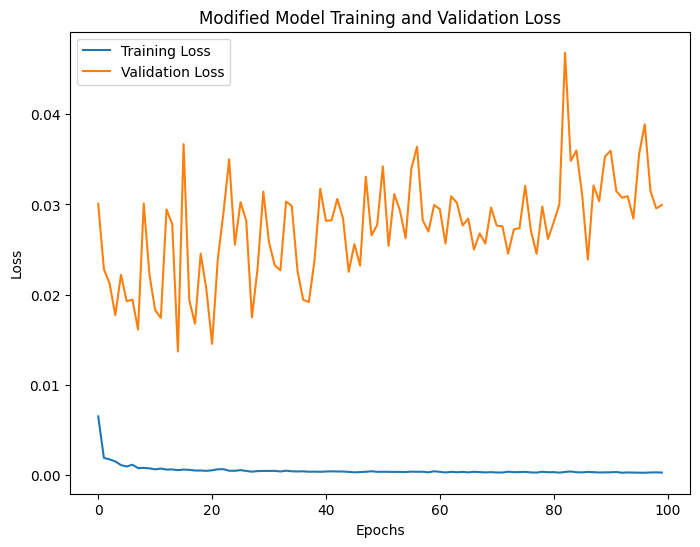

In [77]:
### 5. Building and Training the Modified Model
# Initialize the model
model = Sequential()

# CNN layers
model.add(Conv1D(filters=128, kernel_size=5, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.3))

# Bidirectional LSTM layer
model.add(Bidirectional(LSTM(64, return_sequences=True)))
model.add(Dropout(0.3))

# Additional Bidirectional LSTM layer
model.add(Bidirectional(LSTM(32, return_sequences=False)))
model.add(Dropout(0.3))

# Dense layers
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1))

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error')

# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1, verbose=1)

# Plotting training and validation loss
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Modified Model Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step  
Trend Accuracy (Modified Model): 53.97%
Mean Absolute Percentage Error (MAPE) (Modified Model): 33.38%
Overall Accuracy Score (Modified Model): 66.62%


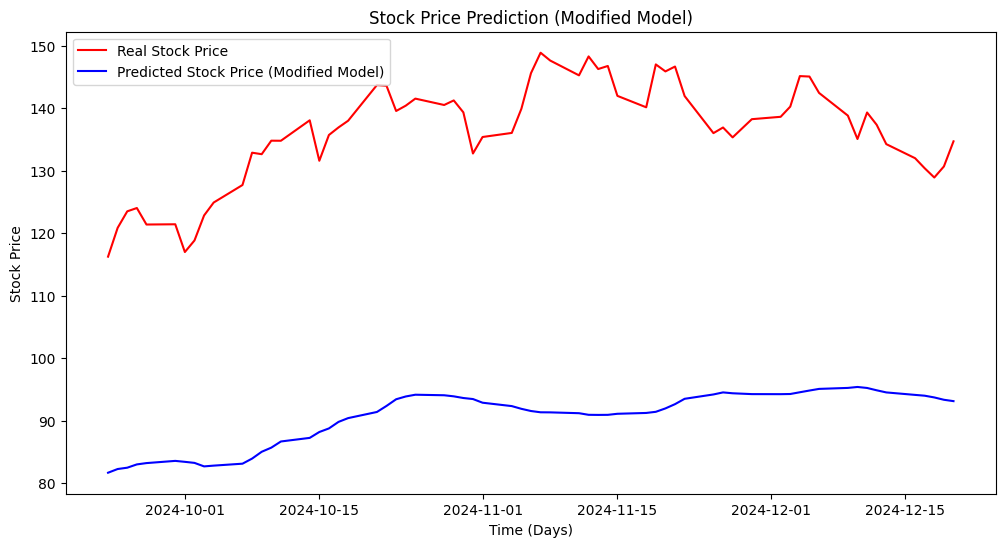

In [78]:
### 6. Preparing Test Data and Making Predictions
# Preparing test data
X_test = []
y_test = test_data['Close'].values[60:]  # Actual 'Close' prices for comparison
for i in range(60, len(scaled_test)):
    X_test.append(scaled_test[i-60:i])
X_test = np.array(X_test, dtype=np.float32)
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], X_test.shape[2]))

# Predicting stock prices
predicted_stock_price = model.predict(X_test, batch_size=32)
predicted_stock_price_expanded = np.zeros((predicted_stock_price.shape[0], scaled_train.shape[1]))
predicted_stock_price_expanded[:, 0] = predicted_stock_price.flatten()
predicted_stock_price = sc.inverse_transform(predicted_stock_price_expanded)[:, 0]

### Backtesting Logic for Modified Model
# Calculating trend accuracy
trend_real = np.sign(np.diff(y_test))  # Actual trends (1 for up, -1 for down, 0 for no change)
trend_predicted = np.sign(np.diff(predicted_stock_price))  # Predicted trends
trend_accuracy = np.mean(trend_real == trend_predicted) * 100

# Calculating price accuracy (Mean Absolute Percentage Error)
mape = np.mean(np.abs((y_test - predicted_stock_price) / y_test)) * 100

# Backtesting summary
overall_accuracy = 100 - mape  # Overall prediction accuracy
print("Trend Accuracy (Modified Model): {:.2f}%".format(trend_accuracy))
print("Mean Absolute Percentage Error (MAPE) (Modified Model): {:.2f}%".format(mape))
print("Overall Accuracy Score (Modified Model): {:.2f}%".format(overall_accuracy))

# Saving backtesting results
backtest_results = pd.DataFrame({
    'Date': test_data['Date'].iloc[61:].values,  # Adjusted for diff()
    'Real Price': y_test[1:],
    'Predicted Price': predicted_stock_price[1:]
})
backtest_results.to_csv("Backtesting_Results_Modified_Model.csv", index=False)

# Plotting fitted data
plt.figure(figsize=(12, 6))
plt.plot(test_data['Date'].iloc[60:], y_test, color='red', label='Real Stock Price')
plt.plot(test_data['Date'].iloc[60:], predicted_stock_price, color='blue', label='Predicted Stock Price (Modified Model)')
plt.title('Stock Price Prediction (Modified Model)')
plt.xlabel('Time (Days)')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

# Saving fitted predictions to CSV
fitted_output = pd.DataFrame({
    'Date': test_data['Date'].iloc[60:].values,
    'Real Price': y_test,
    'Predicted Price': predicted_stock_price.flatten()
})
fitted_output.to_csv("Fitted_Data_Output_Modified_Model.csv", index=False)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


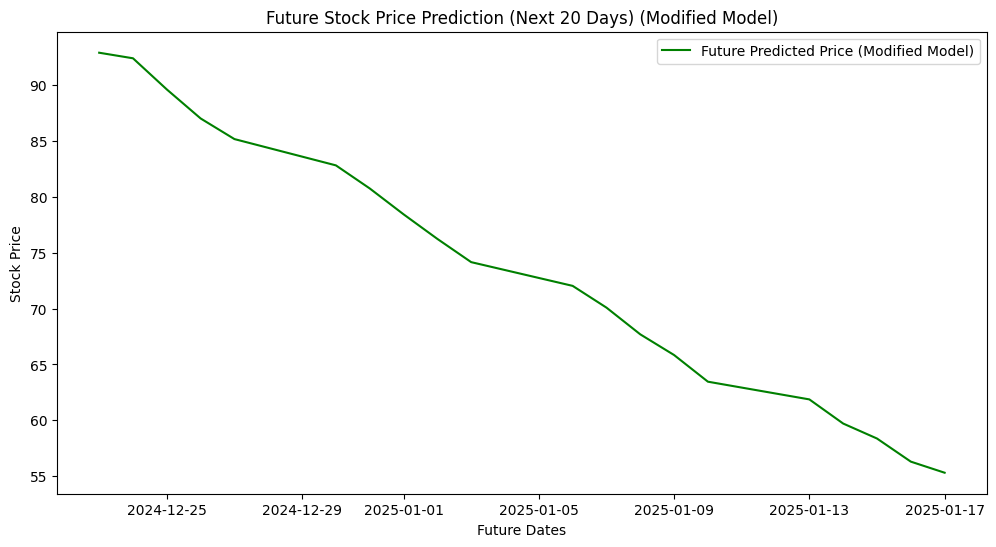

In [79]:
### 7. Future Prediction Logic (20 Days Ahead)
# Starting with the last 60 days of the test set
future_input = scaled_test[-60:]
future_predictions = []

for _ in range(20):
    # Reshape input to match the expected shape
    future_input = future_input.reshape(1, future_input.shape[0], future_input.shape[1])
    future_pred = model.predict(future_input)

    # Append the prediction to the results
    future_predictions.append(future_pred[0, 0])

    # Update the input by appending the prediction and removing the oldest step
    next_step = np.zeros((1, scaled_train.shape[1]))
    next_step[0, 0] = future_pred[0, 0]
    future_input = np.vstack([future_input[0, 1:, :], next_step])

# Rescale predictions back to original range
future_predictions = sc.inverse_transform(
    np.pad(np.array(future_predictions).reshape(-1, 1), ((0, 0), (0, scaled_train.shape[1] - 1)), constant_values=0)
)[:, 0]

# Plotting future predictions
future_dates = pd.date_range(start=test_data['Date'].iloc[-1], periods=21, freq='B')[1:]
plt.figure(figsize=(12, 6))
plt.plot(future_dates, future_predictions, color='green', label='Future Predicted Price (Modified Model)')
plt.title('Future Stock Price Prediction (Next 20 Days) (Modified Model)')
plt.xlabel('Future Dates')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

# Saving future predictions to CSV
future_output = pd.DataFrame({
    'Date': future_dates,
    'Future Predicted Price': future_predictions
})
future_output.to_csv("Future_Predictions_Modified_Model.csv", index=False)